In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import utils
import h5py
import astropy.constants as cons
from matplotlib.colors import LogNorm
import astropy.units as u
import athena_read as ar
import plot_slice
import tde_unit as tde
import pandas as pd
import k3d
from k3d.colormaps import matplotlib_color_maps
import spectrum as sp
from matplotlib.patches import Circle
c=cons.c.cgs.value
G=cons.G.cgs.value
h=cons.h.cgs.value
hbar=h/(2*np.pi)
Msun=cons.M_sun.cgs.value
Mbh=3.0e6*Msun
mp=cons.m_p.cgs.value
me=cons.m_e.cgs.value
kB=cons.k_B.cgs.value
v0=0.0005*c 
mu=0.6
T0=v0**2*mu*mp #temperature unit
rho0=2*G*Mbh/c**2
e= 4.80320425e-10

In [5]:
(2*(e**2)/(3*kB))*(3/(4*np.pi*0.5*mp))**(1/3)

73350.33501470403

In [11]:
esi = 1.602176e-19
mpsi = mp/1e3

In [18]:
150000*1000*(2*(esi**2)*9e9/(3*kB))*(3/(4*np.pi*0.5*mpsi))**(1/3)

110177.82741754536

In [ ]:
3*(esi**2)/(cons.G.si.value*0.5*mpsi)/(cons.M_sun.si.value)

6.938446999005973e-31

In [7]:
3*(e**2)/(G*0.5*mp)/Msun

6.235968906934928e-21

In [21]:
file = np.load('../output/example_disk_formula_i90.npz')
print(list(file.keys()))

['mass_msun', 'width', 'frequency', 'adaptive_num_levels', 'I_nu', 'emission', 'tau']


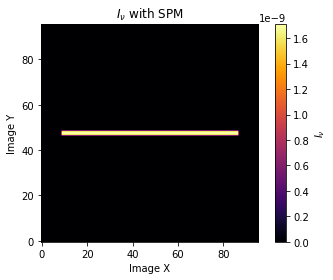

In [22]:
frequencies = np.array(file['frequency'][11])
plt.imshow(file['I_nu'][11],cmap='inferno',origin='lower')
plt.colorbar(label="$I_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.title('$I_\\nu$ with SPM')
#plt.savefig('../plots/tde_I_nu_spm.png', bbox_inches='tight', dpi=300)
plt.show()

In [10]:
def get_Bnu(x,T=3*3649):
    frequencies = x
    return 2*h*(frequencies**3)/c**2/(np.exp(h*frequencies/(kB*T))-1)

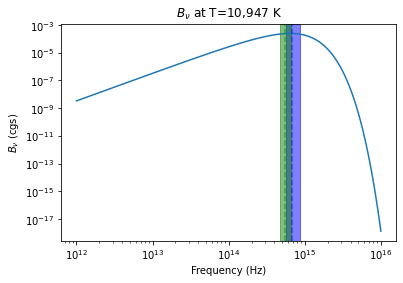

In [5]:
freq = np.logspace(12,16,100)
plt.plot(freq,get_Bnu(freq,3*3649))
plt.axvline(6.78e14,color='blue',linestyle='--',alpha=0.5)
plt.axvspan(5.593e14,8.6147e14,color='blue',alpha=0.5)
plt.axvline(5.55e14,color='green',linestyle='--',alpha=0.5)
plt.axvspan(4.77e14,6.63e14,color='green',alpha=0.5)
#plt.axvspan(6.78e14-3.189e15,6.78e14+3.189e15,color='blue',linestyle='--',alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('$B_\\nu$ (cgs)')
plt.title('$B_\\nu$ at T=10,947 K')
plt.show()

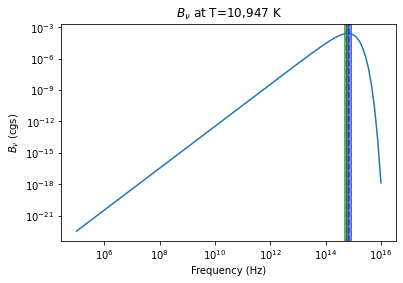

In [7]:
freq = np.logspace(5,16,100)
plt.plot(freq,get_Bnu(freq,3*3649))
plt.axvline(6.78e14,color='blue',linestyle='--',alpha=0.5)
plt.axvspan(5.593e14,8.6147e14,color='blue',alpha=0.5)
plt.axvline(5.55e14,color='green',linestyle='--',alpha=0.5)
plt.axvspan(4.77e14,6.63e14,color='green',alpha=0.5)
#plt.axvspan(6.78e14-3.189e15,6.78e14+3.189e15,color='blue',linestyle='--',alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('$B_\\nu$ (cgs)')
plt.title('$B_\\nu$ at T=10,947 K')
plt.show()

In [12]:
import scipy.integrate as integrate
fullResult = integrate.quad(get_Bnu,1e5,1e16)
partialResut = integrate.quad(get_Bnu,4.77e14,6.63e14)

In [17]:
partialResut[0]/fullResult[0]

0.17364124732577216

In [15]:
partialResut

(45008571894.105446, 0.0004996955282233256)

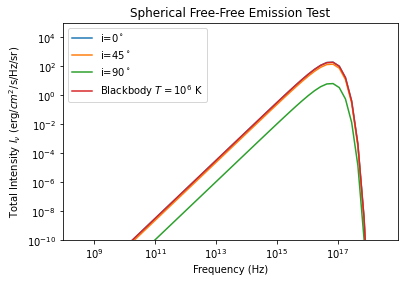

In [14]:
testFile = np.load('../output/example_disk_formula_i0.npz')
I_nu_i0 = np.nanmean(testFile['I_nu'], axis=(1,2))
plt.plot(testFile['frequency'], I_nu_i0,label='i=0$^\\circ$')

testFile = np.load('../output/example_disk_formula_i45.npz')
I_nu_i45 = np.nanmean(testFile['I_nu'], axis=(1,2))
plt.plot(testFile['frequency'], I_nu_i45,label='i=45$^\\circ$') 

testFile = np.load('../output/example_disk_formula_i90.npz')
I_nu_i90 = np.nanmean(testFile['I_nu'], axis=(1,2))
plt.plot(testFile['frequency'], I_nu_i90,label='i=90$^\\circ$')

B_nu = get_Bnu(testFile['frequency'],1e6)
plt.plot(testFile['frequency'], B_nu, label='Blackbody $T=10^6$ K')
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-10,1e5)
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Total Intensity $I_\\nu$ (erg/$cm^2$/s/Hz/sr)')
plt.title('Spherical Free-Free Emission Test')
plt.show()

In [51]:
I_nu_i0/get_Bnu(testFile['frequency'],1e6)

array([1.03645833, 1.03645833, 1.03645833, 1.03645833, 1.03645833,
       1.03645833, 1.03645833, 1.03645833, 1.03645833, 1.03645833,
       1.03645833, 1.03645833, 1.03645833, 1.03645833, 1.03645833,
       1.03645833, 1.03645833, 1.03645833, 1.03645833, 1.03645833,
       1.03645833, 1.03645833, 1.03645833, 1.03645833, 1.03645833,
       1.03645833, 1.03645833, 1.03645833, 1.03645833, 1.03645833,
       1.03645833, 1.03645833, 1.03645833, 1.03645833, 1.03645833,
       1.03645833, 1.03645833, 1.03645833, 1.03645833, 1.03645833,
       1.03645833, 1.03645833, 1.03645833, 1.03645833, 1.03645833,
       1.03645833, 1.03645833, 1.03645833, 1.03645833, 1.03645833])

In [15]:
distance_cm = G*1200 * Msun * 1e6 / c**2
width = 2.0*np.pi * np.arctan(0.5*500 /(1200))
width_cm = G*500*Msun * 1e6 / c**2
disk_radii_cm = G*200*Msun * 1e6 / c**2
disk_height_cm = G*10*Msun * 1e6 / c**2
sphere_cm = G*200*Msun * 1e6 / c**2

B_nu = get_Bnu(np.logspace(1,19,500),1e6)
F_nu = B_nu*np.pi*(sphere_cm/distance_cm)**2
L_nu = F_nu * 4*np.pi*distance_cm**2

In [25]:
np.average(I_nu_i0)

13.826423503497665

In [26]:
np.average(I_nu_i90)

0.4620655669549347

In [16]:
def get_disk_conversion(inc):
    dOmega = (np.arctan(0.5*width_cm /(distance_cm)))**2
    dA = 4*np.pi*distance_cm**2
    #with the below option there was a factor of about 0.11 in luminosity of i90/i0
    #dOmega = np.cos(np.radians(inc))*(np.pi*(sphere_cm/distance_cm)**2) + np.sin(np.radians(inc))*(2*disk_radii_cm*disk_height_cm/distance_cm**2)
    #dOmega = 4*disk_radii_cm*disk_height_cm/distance_cm**2 - disk_radii_cm*(disk_height_cm**3)/(4*distance_cm**4)*np.sin(np.radians(inc))

    #with the dOmega I have here I get a factor of -0.11
    #dOmega = np.cos(np.radians(inc))*(np.pi*(sphere_cm/distance_cm)**2) + np.sin(np.radians(inc))*(disk_radii_cm/(3*distance_cm**4)*(disk_radii_cm**2*disk_height_cm + disk_height_cm**3/4 -6*distance_cm**2*disk_height_cm))
    return dA*dOmega

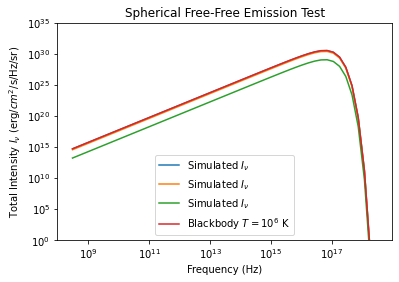

In [17]:

#*(width ** 2)*(width_cm**2)

#the luminosity should be the same regardless of distance but it's not for some reason
#when i do it the way from before i basically am just doing I_nu times 2 pi^2 d^2
#when i do it this way i get I_nu times 2 pi^2 r^2
#to have the same energy overall you would need the first option to have a smaller I_nu by (r/d)^2
#the second way is better because physically the energy is 

#the first way is basically saying that it takes up the full distance and the full image size 
plt.plot(testFile['frequency'], I_nu_i0*get_disk_conversion(0),label='Simulated $I_\\nu$')
plt.plot(testFile['frequency'], I_nu_i45*get_disk_conversion(45),label='Simulated $I_\\nu$')
plt.plot(testFile['frequency'], I_nu_i90*get_disk_conversion(90),label='Simulated $I_\\nu$')

B_nu = get_Bnu(testFile['frequency'],1e6)
plt.plot(testFile['frequency'], B_nu*2*(np.pi*disk_radii_cm)**2, label='Blackbody $T=10^6$ K')

plt.yscale('log')
plt.xscale('log')
plt.ylim(1e0,1e35)
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Total Intensity $I_\\nu$ (erg/$cm^2$/s/Hz/sr)')
plt.title('Spherical Free-Free Emission Test')
plt.show()

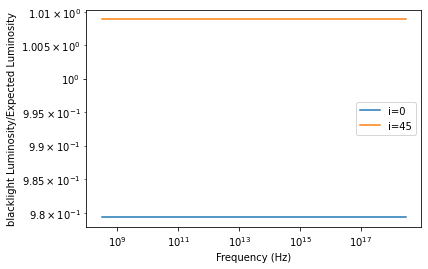

In [27]:

B_nu = get_Bnu(testFile['frequency'],1e6)
plt.plot(testFile['frequency'], I_nu_i0*get_disk_conversion(0)/(B_nu*2*np.cos(np.radians(0))*(np.pi*disk_radii_cm)**2), label='i=0')
plt.plot(testFile['frequency'], I_nu_i45*get_disk_conversion(45)/(B_nu*2*np.cos(np.radians(45))*(np.pi*disk_radii_cm)**2), label='i=45')
#plt.plot(testFile['frequency'], I_nu_i90*get_disk_conversion(90)/(B_nu*2*np.cos(np.radians(90))*(np.pi*disk_radii_cm)**2), label='i=90')

plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('blacklight Luminosity/Expected Luminosity')
plt.show()

In [11]:
(I_nu_i0*get_disk_conversion(0))/(B_nu*2*(np.pi*sphere_cm)**2)

array([1.00211104, 1.00211105, 1.00211105, 1.00211105, 1.00211105,
       1.00211105, 1.00211105, 1.00211105, 1.00211105, 1.00211105,
       1.00211105, 1.00211105, 1.00211105, 1.00211105, 1.00211105,
       1.00211105, 1.00211105, 1.00211105, 1.00211105, 1.00211105,
       1.00211105, 1.00211105, 1.00211105, 1.00211105, 1.00211105,
       1.00211105, 1.00211105, 1.00211105, 1.00211105, 1.00211105,
       1.00211105, 1.00211105, 1.00211105, 1.00211105, 1.00211105,
       1.00211105, 1.00211105, 1.00211105, 1.00211105, 1.00211105,
       1.00211105, 1.00211105, 1.00211105, 1.00211105, 1.00211105,
       1.00211105, 1.00211105, 1.00211105, 1.00211105, 1.00211105])